# Operator Dynamics in Random Bricklayer Circuits with Pauli Propagation and MPO

The goal of this notebook is to study the time evolution of a local quantum observable using the Pauli propagation framework implemented in `PauliPropagation.jl` and compare it to the exact diagonalisation and MPO method.



In [2]:
# using Pkg; Pkg.add("LaTeXStrings"); Pkg.add("PauliPropagation"); Pkg.add("ITensors"); Pkg.add("ITensorMPS")

In [24]:
using LaTeXStrings
using Plots
using LinearAlgebra
import Statistics: mean

# --- Pauli Propagation ---
using PauliPropagation

#include("../src/pauli_propagation_functions.jl")
include("pauli_propagation_functions.jl")
import .pauli_propagation_functions as pp

# --- MPO ---
using ITensors, ITensorMPS

#include("../src/matrix_product_operator_functions.jl")
include("matrix_product_operator_functions.jl")
import .mpo_functions as mpo

# --- Exact method ---

#include("../src/exact_functions.jl")
include("exact_functions.jl")
import .exact_functions as ext

# --- Circuit ---
include("circuit.jl")
import .circuit as circuit

---

# 1. Random Gate Circuit

We will use a random circuits of the form:

$$
U = \prod_j e^{i \theta_j P_j}
$$

where:

- $\theta_j$ are random angles
- $P_j$ are random two-qubit Pauli strings

We need a **uniform distribution** for these random doors, so we will use the **Haar distribution**.

---

## 1.1 Mezzadri algo for Haar distribution

1.  **Generation of $Z$**: We create an $n \times n$ matrix where each element is a complex number $a + ib$, with $a, b \sim \mathcal{N}(0, 1)$.
2.  **QR decomposition**: We compute $Q$ and $R$ such that $Z = QR$.
3.  **Phase correction**: We define a diagonal matrix $\Lambda$ such that:
$$\Lambda_{ii} = \frac{R_{ii}}{|R_{ii}|}$$
  The diagonal elements of $R' = \Lambda^{-1}R$ are always real and strictly positive, therefore the matrix $Q' = Q\Lambda$ is **distributed with Haar measure**.

We then compute the final unitary matrix: $U = Q \times \Lambda$.



In [20]:
U = circuit.haar_unitary(4)

4×4 Matrix{ComplexF64}:
   0.306408-0.253254im   -0.378046-0.137338im  …    0.729553+0.325614im
  -0.126696-0.161112im   -0.152039+0.088737im     -0.0701558-0.107501im
  -0.831346+0.260555im  -0.0542311-0.335572im       0.307662+0.14883im
 -0.0170746+0.20162im     0.539308+0.633109im       0.387795+0.279389im

And we can verify if $U$ is unitary.

In [21]:
U * U' ≈ U' * U ≈ I(4)

true

---

## 1.2 Matrices to gates

Now we want to use these random unitary matrices as gates to build a quantum circuit of the type :

<img src="https://github.com/TheoHUETQC/Quantum-ManyBody-Sim-Methods/blob/main/figures/brickwork_pattern_circuit.png?raw=1" width="600" alt="Block circuit">

All U are different random 4x4 matrices.

To use the random matrices we have and will construct as gates, we will need to apply transformations to them. In fact, each method requires the gate to be of a certain type.

- For the PauliPropagation method, the package allows us to do this using the function `TransferMapGate()`,
- The MPO method need to convert the matrix in tensor which will apply to sites[i], sites[j], we use `itensor()`,
- And for the exact method, we need to transform $U$, which is a $4\times 4$ matrix, into a matrix of size $2^N \times 2^N$: $\mathbb{I} \otimes \dots \otimes U \otimes \dots \otimes \mathbb{I}$, we use the function `local_to_global_matrices()`.

In [27]:
# circuit.matrix_to_gate(U, (1,2), 4)

---

# 2. test the implementation of the circuit

## 2.1 initialisation

In [ ]:
nqubits = 8
nlayers = 100

topology = bricklayertopology(nqubits; periodic=false)

# creation des sites, on a besoin de l'init avant le circuit
sites = ITensors.siteinds("Qubit", nqubits)

# define the circuit
circuit_pp, circuit_mpo, circuit_exact = circuit.random_circuit(nqubits, nlayers; topology)

# for Z_i
i= nqubits ÷ 2

4

### Exact

In [ ]:
# psi0
ψ0_exact = append!([1.],[0. for _ in 2:(2^nqubits)]) # |0> state

# Z_i
Z_i_exact = ext.get_Zi(nqubits, i)

256×256 Matrix{ComplexF64}:
 1.0+0.0im  0.0+0.0im  0.0+0.0im  …   0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  1.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  1.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …   0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …   0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im      0.0+0.0im   0.0+0.0im   0.0+0.0im
    ⋮                             ⋱ 

### Pauli Propagation

In [ ]:
# the truncations
max_weight = nqubits
min_abs_coeff = 0.

# psi0
ψ0_pp = ψ0_exact # |0> state

# Z_i
Z_i_pp = PauliString(nqubits, :Z, i) # I...IZI...I

PauliString(nqubits: 8, 1.0 * IIIZIIII)

### MPO

In [ ]:
# the truncations
cutoff = 0.
maxdim = 2^nqubits

# psi0
ψ0_mps = MPS(sites, "0") # |↑↑..↑>

# Z_i
ops = ["Id" for n in 1:nqubits]
ops[i] = "Z"
Z_i_mpo = MPO(sites, ops)

8-element MPO:
 ((dim=2|id=724|"Qubit,Site,n=1")', (dim=2|id=724|"Qubit,Site,n=1"), (dim=1|id=735|"Link,l=1"))
 ((dim=2|id=323|"Qubit,Site,n=2")', (dim=2|id=323|"Qubit,Site,n=2"), (dim=1|id=37|"Link,l=2"), (dim=1|id=735|"Link,l=1"))
 ((dim=2|id=981|"Qubit,Site,n=3")', (dim=2|id=981|"Qubit,Site,n=3"), (dim=1|id=747|"Link,l=3"), (dim=1|id=37|"Link,l=2"))
 ((dim=2|id=804|"Qubit,Site,n=4")', (dim=2|id=804|"Qubit,Site,n=4"), (dim=1|id=4|"Link,l=4"), (dim=1|id=747|"Link,l=3"))
 ((dim=2|id=105|"Qubit,Site,n=5")', (dim=2|id=105|"Qubit,Site,n=5"), (dim=1|id=183|"Link,l=5"), (dim=1|id=4|"Link,l=4"))
 ((dim=2|id=619|"Qubit,Site,n=6")', (dim=2|id=619|"Qubit,Site,n=6"), (dim=1|id=344|"Link,l=6"), (dim=1|id=183|"Link,l=5"))
 ((dim=2|id=963|"Qubit,Site,n=7")', (dim=2|id=963|"Qubit,Site,n=7"), (dim=1|id=717|"Link,l=7"), (dim=1|id=344|"Link,l=6"))
 ((dim=2|id=23|"Qubit,Site,n=8")', (dim=2|id=23|"Qubit,Site,n=8"), (dim=1|id=717|"Link,l=7"))

---

## 2.2 Propagation

In [ ]:
println("Exact method")
Z_it_exact, result_exact = ext.propagate_layerbylayer(circuit_exact, Z_i_exact; ψ0=ψ0_exact)
println("---\n Z_i(t_final) :")
Z_it_exact

Exact method
layer : 10 /100 complete
layer : 20 /100 complete
layer : 30 /100 complete
layer : 40 /100 complete
layer : 50 /100 complete
layer : 60 /100 complete
layer : 70 /100 complete
layer : 80 /100 complete
layer : 90 /100 complete
layer : 100 /100 complete
Time taken by ext.propagate_layerbylayer: 8.656738996505737 seconds
---
 Z_i(t_final) :


256×256 Matrix{ComplexF64}:
  -0.0472337-3.81639e-17im  …    0.0113326-0.0200599im
  -0.0280939-0.0391521im        -0.0128391+0.0166818im
  -0.0648376-0.0658401im         0.0563512-0.0926375im
   0.0472251-0.0165688im         0.0426135+0.0621492im
  -0.0457993+0.0307233im         -0.018627-0.0350534im
   0.0228951-0.00262318im   …    0.0104001-0.0349727im
 -0.00308703-0.0640853im        -0.0225696-0.0316936im
   0.0658522+0.0681251im        -0.0250478+0.0605954im
  -0.0432852-0.035833im         -0.0318893-0.00512525im
   0.0988854+0.0334907im        -0.0155753-0.0292324im
   0.0222303+0.0503512im    …   -0.0191575+0.00682287im
   0.0119028-0.034897im          0.0890786+0.0762548im
   0.0468203-0.0166673im         0.0448519+0.0111046im
            ⋮               ⋱             ⋮
  -0.0417517-0.0548637im        -0.0158817+0.00434783im
  -0.0757223+0.122968im     …    0.0483913+0.0849426im
  -0.0250778-0.012085im          0.0148021-0.027979im
   -0.069242-0.0299343im         0.0302258-0.0

In [ ]:
println("Pauli Propagation method")
Z_it_pp, result_pp = pp.propagate_layerbylayer(circuit_pp, Z_i_pp, nlayers; max_weight, min_abs_coeff, ψ0=ψ0_pp)
println("---")

Pauli Propagation method
layer : 10/100 complete
layer : 20/100 complete
layer : 30/100 complete
layer : 40/100 complete
layer : 50/100 complete
layer : 60/100 complete
layer : 70/100 complete
layer : 80/100 complete
layer : 90/100 complete
layer : 100/100 complete
Time taken by pp.propagate_layerbylayer: 159.08237600326538 seconds
---


In [ ]:
println("Matrix Product Operator method")
Z_it_mpo, result_mpo = mpo.propagate_layerbylayer(circuit_mpo, Z_i_mpo; cutoff, maxdim, ψ0=ψ0_mps)
println("---")

Matrix Product Operator method
layer : 10 /100 complete
layer : 20 /100 complete
layer : 30 /100 complete
layer : 40 /100 complete
layer : 50 /100 complete
layer : 60 /100 complete
layer : 70 /100 complete
layer : 80 /100 complete
layer : 90 /100 complete
layer : 100 /100 complete
Time taken by mpo_functions.propagate_layerbylayer: 109.80295610427856 seconds
---


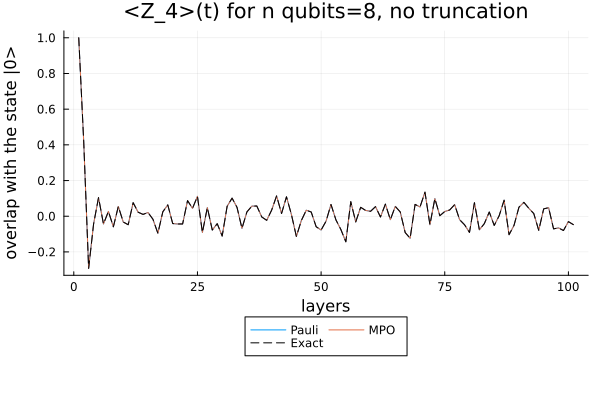

In [ ]:
overlap_pp = result_pp["overlap"]
overlap_mpo = result_mpo["overlap"]
overlap_exact = result_exact["overlap"]

p = plot(title="<Z_$i>(t) for n qubits=$nqubits, no truncation", xlabel="layers", ylabel="overlap with the state |0>")

plot!(p, 1:length(overlap_pp), overlap_pp, label="Pauli")
plot!(p, 1:length(overlap_mpo), overlap_mpo, label="MPO")
plot!(p, 1:length(overlap_exact), overlap_exact, label="Exact", line = (1, :dash), color=:black)
plot!(legend=:outerbottom, legendcolumns=2)

display(p)

---

# 3. Compute complexity

## 3.1 Test truncation function

In [ ]:
function test_truncation_pp(truncations::Union{Vector{Tuple{Int64, Float64}}, Tuple{Int64, Float64}}, tolerance::Float64=1e-4)
  overlaps, norms = Vector{}[], Vector{}[]
  optimal_truncation = nothing

  for (max_weight, min_abs_coeff) in truncations
    println("Max weight = $max_weight, Min abs coeff = $min_abs_coeff")
    # propagation
    Zi_t_pauli_propagation, result_pp = pp.propagate_layerbylayer(circuit_pp, Z_i_pp, nlayers; max_weight, min_abs_coeff)

    # result
    overlap_pp = result_pp["overlap"]
    push!(overlaps, overlap_pp)
    push!(norms, result_pp["norm"])

    # print difference between Zi(t)
    Zi_t_pauli_propagation_matrix = pp.compute_matrix(Zi_t_pauli_propagation)
    isclose_matrix = isapprox(Zi_t_pauli_propagation_matrix, Zi_t_exact; rtol=tolerance)
    isclose_overlap = isapprox(overlap_pp, overlap_exact; rtol=tolerance)
    println("Z_$i (t_final) are close for the two methods (with a tolerance=$tolerance) ? ", isclose_matrix)
    println("the overlap's curve are close for the two methods (with a tolerance=$tolerance) ? ", isclose_overlap)
    if isclose_matrix && isclose_overlap
      optimal_truncation = (max_weight, min_abs_coeff)
      println("Optimal trincation find : $optimal_truncation; in the list : $truncations")
      println("---")
      break
    end
    println("---")
  end
  if optimal_truncation == nothing
    optimal_truncation = (nqubits, 0.)
    println("No truncation found in $truncations; default: $optimal_truncation (no truncation)")
  end
  return overlaps, norms, optimal_truncation
end

#min_abs_coeff_idx = round.(Int, range(2, 4))

test_truncation_pp (generic function with 2 methods)

In [ ]:
function test_truncation_mpo(truncations::Union{Vector{Tuple{Int64, Float64}}, Tuple{Int64, Float64}}, tolerance::Float64=1e-4)
  overlaps, norms = Vector{}[], Vector{}[]
  optimal_truncation = nothing

  for (maxdim, cutoff) in truncations
    println("Max dim = $maxdim, Cutoff = $cutoff")
    # propagation
    Zi_t_mpo, result_mpo = mpo.propagate_layerbylayer(circuit_mpo, Z_i_mpo; cutoff, maxdim)

    # result
    overlap_mpo = result_mpo["overlap"]
    push!(overlaps, overlap_mpo)
    push!(norms, result_mpo["norm"])

    # print difference between Zi(t)
    #Zi_t_mpo_matrix = mpo.compute_matrix(Zi_t_mpo, sites)
    #isclose_matrix = isapprox(Zi_t_mpo_matrix, Zi_t_exact; rtol=tolerance)
    isclose_overlap = isapprox(overlap_mpo, overlap_exact; rtol=tolerance)
    #println("Z_$i (t_final) are close for the two methods (with a tolerance=$tolerance) ? ", isclose_matrix)
    println("the overlap's curve are close for the two methods (with a tolerance=$tolerance) ? ", isclose_overlap)
    if isclose_overlap
      optimal_truncation = (maxdim, cutoff)
      println("Optimal trincation find : $optimal_truncation; in the list : $truncations")
      println("---")
      break
    end
    println("---")
  end
  if optimal_truncation == nothing
    optimal_truncation = (2^nqubits, 0.)
    println("No truncation found in $truncations; default: $optimal_truncation (no truncation)")
  end
  return overlaps, norms, optimal_truncation
end

test_truncation_mpo (generic function with 2 methods)

---

## 3.2 Cumpute complexity

In [ ]:
nlayers = 100
i= 2
tolerance = 1e-2

0.01

--------- 3 qubits ---------
--------- 1. Exact method propagation ---------
layer : 10 /100 complete
layer : 20 /100 complete
layer : 30 /100 complete
layer : 40 /100 complete
layer : 50 /100 complete
layer : 60 /100 complete
layer : 70 /100 complete
layer : 80 /100 complete
layer : 90 /100 complete
layer : 100 /100 complete
Time taken by ext.propagate_layerbylayer: 0.0036640167236328125 seconds
--------- 2. Pauli propagation ---------
------ 2.1 Max weight TEST ------
Max weight = 2, Min abs coeff = 1.0e-6
layer : 10/100 complete
layer : 20/100 complete
layer : 30/100 complete
layer : 40/100 complete
layer : 50/100 complete
layer : 60/100 complete
layer : 70/100 complete
layer : 80/100 complete
layer : 90/100 complete
layer : 100/100 complete
Time taken by pp.propagate_layerbylayer: 0.8212800025939941 seconds
Z_2 (t_final) are close for the two methods (with a tolerance=0.01) ? false
the overlap's curve are close for the two methods (with a tolerance=0.01) ? false
---
Max weight = 3,

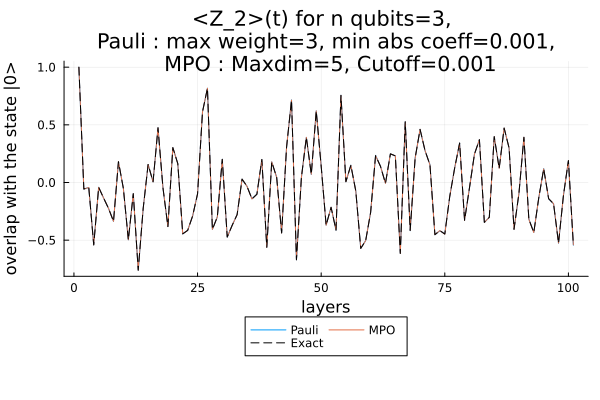

--------- 5 qubits ---------
--------- 1. Exact method propagation ---------
layer : 10 /100 complete
layer : 20 /100 complete
layer : 30 /100 complete
layer : 40 /100 complete
layer : 50 /100 complete
layer : 60 /100 complete
layer : 70 /100 complete
layer : 80 /100 complete
layer : 90 /100 complete
layer : 100 /100 complete
Time taken by ext.propagate_layerbylayer: 0.028976917266845703 seconds
--------- 2. Pauli propagation ---------
------ 2.1 Max weight TEST ------
Max weight = 4, Min abs coeff = 1.0e-6
layer : 10/100 complete
layer : 20/100 complete
layer : 30/100 complete
layer : 40/100 complete
layer : 50/100 complete
layer : 60/100 complete
layer : 70/100 complete
layer : 80/100 complete
layer : 90/100 complete
layer : 100/100 complete
Time taken by pp.propagate_layerbylayer: 0.699603796005249 seconds
Z_2 (t_final) are close for the two methods (with a tolerance=0.01) ? false
the overlap's curve are close for the two methods (with a tolerance=0.01) ? false
---
Max weight = 5, M

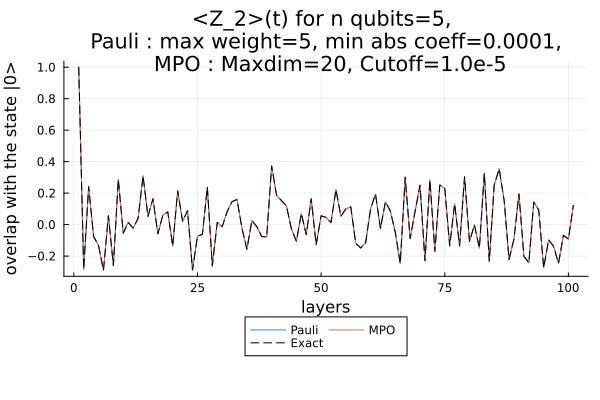

--------- 7 qubits ---------
--------- 1. Exact method propagation ---------
layer : 10 /100 complete
layer : 20 /100 complete
layer : 30 /100 complete
layer : 40 /100 complete
layer : 50 /100 complete
layer : 60 /100 complete
layer : 70 /100 complete
layer : 80 /100 complete
layer : 90 /100 complete
layer : 100 /100 complete
Time taken by ext.propagate_layerbylayer: 1.9816529750823975 seconds
--------- 2. Pauli propagation ---------
------ 2.1 Max weight TEST ------
Max weight = 6, Min abs coeff = 1.0e-6
layer : 10/100 complete
layer : 20/100 complete
layer : 30/100 complete
layer : 40/100 complete
layer : 50/100 complete
layer : 60/100 complete
layer : 70/100 complete
layer : 80/100 complete
layer : 90/100 complete
layer : 100/100 complete
Time taken by pp.propagate_layerbylayer: 23.682152032852173 seconds
Z_2 (t_final) are close for the two methods (with a tolerance=0.01) ? false
the overlap's curve are close for the two methods (with a tolerance=0.01) ? false
---
Max weight = 7, Mi

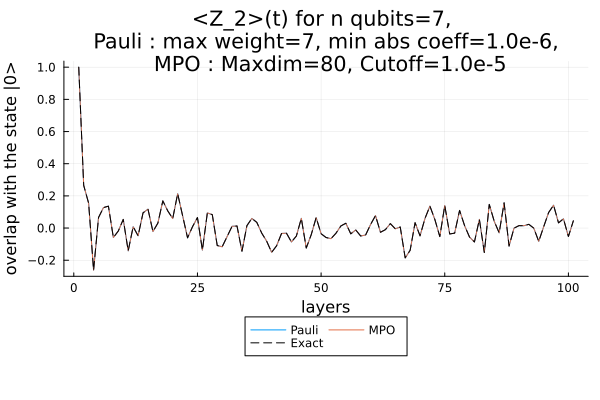

--------- 9 qubits ---------
--------- 1. Exact method propagation ---------
layer : 10 /100 complete
layer : 20 /100 complete
layer : 30 /100 complete
layer : 40 /100 complete
layer : 50 /100 complete
layer : 60 /100 complete
layer : 70 /100 complete
layer : 80 /100 complete
layer : 90 /100 complete
layer : 100 /100 complete
Time taken by ext.propagate_layerbylayer: 71.00368309020996 seconds
--------- 2. Pauli propagation ---------
------ 2.1 Max weight TEST ------
Max weight = 8, Min abs coeff = 1.0e-6
layer : 10/100 complete
layer : 20/100 complete
layer : 30/100 complete
layer : 40/100 complete
layer : 50/100 complete
layer : 60/100 complete
layer : 70/100 complete
layer : 80/100 complete
layer : 90/100 complete
layer : 100/100 complete
Time taken by pp.propagate_layerbylayer: 872.5475800037384 seconds
Z_2 (t_final) are close for the two methods (with a tolerance=0.01) ? false
the overlap's curve are close for the two methods (with a tolerance=0.01) ? false
---
Max weight = 9, Min 

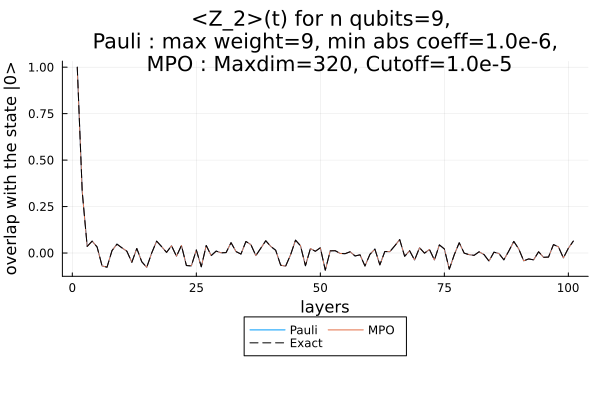

In [ ]:
times_exact, times_pp, times_mpo = Float64[], Float64[], Float64[]
truncations_mpo, truncations_pp = Tuple{Int64, Float64}[], Tuple{Int64, Float64}[]

Ns = 3:2:9
for nqubits in Ns
  println("--------- $nqubits qubits ---------")
  topology = bricklayertopology(nqubits; periodic=false)
  sites = ITensors.siteinds("Qubit", nqubits)
  circuit_pp, circuit_mpo, circuit_exact = circuit.random_circuit(nqubits, nlayers; topology)

  # ------------------------------ exact ------------------------------
  # Exact method
  println("--------- 1. Exact method propagation ---------")
  Z_i = ext.get_Zi(nqubits, i)
  Zi_t_exact, result_exact = ext.propagate_layerbylayer(circuit_exact, Z_i)
  global Zi_t_exact
  overlap_exact = result_exact["overlap"]

  # ------------------------------ Pauli ------------------------------

  println("--------- 2. Pauli propagation ---------")
  # Init pp method
  Z_i_pp = PauliString(nqubits, :Z, i) # I...IZI...I

  # test truncation
  ## Max weight
  println("------ 2.1 Max weight TEST ------")
  min_abs_coeff_power = -6
  max_weight_list = nqubits-1:nqubits
  truncations = [(max_weight_list[i], 10. ^(min_abs_coeff_power)) for i in 1:length(max_weight_list)]
  overlap_max_weight, _, (max_weight_optimal, _) = test_truncation_pp(truncations, tolerance)

  ## Min abs coeff
  println("------ 2.2 Min abs coeff TEST ------")
  max_weight = max_weight_optimal
  min_abs_coeff_power = -round.(Int, range(3, 6, 3))
  truncations = [(max_weight, 10. ^(min_abs_coeff_power[i])) for i in 1:length(min_abs_coeff_power)]
  overlap_min_abs_coeff, _, (_, min_abs_coeff_optimal) = test_truncation_pp(truncations, tolerance)

  # optimal truncation application
  println("--------- 2.3 Propagation with optimal truncations ---------")
  Zi_t_pauli_propagation, result_pp = pp.propagate_layerbylayer(circuit_pp, Z_i_pp, nlayers; max_weight=max_weight_optimal, min_abs_coeff=min_abs_coeff_optimal)
  overlap_pp = result_pp["overlap"]

  # ------------------------------ mpo ------------------------------

  println("--------- 3. MPO method propagation ---------")
  # Init mpo method
  ops = ["Id" for n in 1:nqubits]
  ops[i] = "Z"
  Z_i_mpo = MPO(sites, ops)
  dim = 2^nqubits

  # test truncation
  ## Max dim
  println("------ 3.1 Max dim TEST ------")
  cutoff_power = -9
  maxdim_list = round.(Int, range(dim/1.6, dim, 5))
  truncations = [(maxdim_list[i], 10. ^(cutoff_power)) for i in 1:length(maxdim_list)]
  overlap_maxdim, _, (maxdim_optimal, _) = test_truncation_mpo(truncations, tolerance)

  ## cutoff
  println("------ 3.2 cutoff TEST ------")
  maxdim = maxdim_optimal
  cutoff_power = -round.(Int, range(3, 9, 4))
  truncations = [(maxdim, 10. ^(cutoff_power[i])) for i in 1:length(min_abs_coeff_power)]
  overlap_cutoff, _, (_, cutoff_optimal) = test_truncation_mpo(truncations, tolerance)

  # optimal truncation application
  println("------ 3.3 Propagation with optimal truncations ------")
  Zi_t_mpo, result_mpo = mpo.propagate_layerbylayer(circuit_mpo, Z_i_mpo; maxdim=maxdim_optimal, cutoff=cutoff_optimal)
  overlap_mpo = result_mpo["overlap"]

  # ------------------------------ plot ------------------------------
  println("--------- 4. plots ---------")
  # to see if its good
  p = plot(title="<Z_$i>(t) for n qubits=$nqubits, \n Pauli : max weight=$max_weight_optimal, min abs coeff=$min_abs_coeff_optimal, \n MPO : Maxdim=$maxdim_optimal, Cutoff=$cutoff_optimal", xlabel="layers", ylabel="overlap with the state |0>")
  plot!(p, overlap_pp, label="Pauli")
  plot!(p, overlap_mpo, label="MPO")
  plot!(p, overlap_exact, label="Exact", line = (1, :dash), color=:black)
  plot!(legend=:outerbottom, legendcolumns=2)
  display(p)

  # ------------------------------ result ------------------------------

  # push the time of propagation to see complexity
  push!(truncations_pp, (max_weight_optimal, min_abs_coeff_optimal))
  push!(truncations_mpo, (maxdim_optimal, cutoff_optimal))
  push!(times_exact, result_exact["time"])
  push!(times_pp, result_pp["time"])
  push!(times_mpo, result_mpo["time"])
end


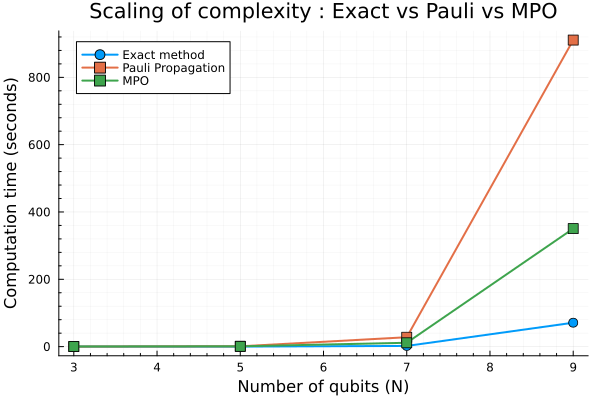

In [ ]:
plot(Ns, [times_exact, times_pp, times_mpo],
    label = ["Exact method" "Pauli Propagation" "MPO"],
    marker = [:circle :square :square],     # Ajout de points pour voir les mesures réelles
    markersize = 5,
    lw = 2,                        # Épaisseur de ligne
    xlabel = "Number of qubits (N)",
    ylabel = "Computation time (seconds)",
    title = "Scaling of complexity : Exact vs Pauli vs MPO",
    subtitle = "TFIM Circuit",
    legend = :topleft,
    grid = :both,
    minorgrid = true
)

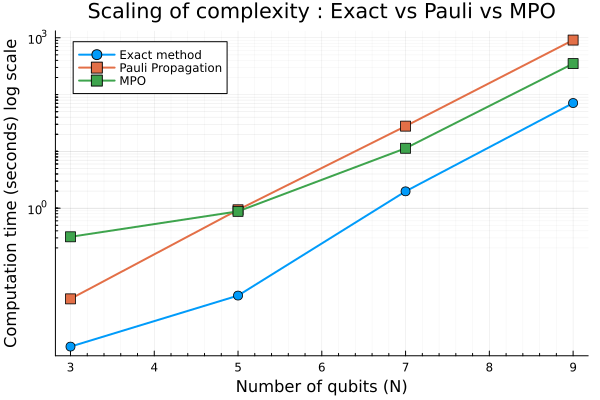

In [ ]:
plot(Ns, [times_exact, times_pp, times_mpo],
    label = ["Exact method" "Pauli Propagation" "MPO"],
    yaxis = :log10,                # Passage en échelle semi-log
    marker = [:circle :square :square],     # Ajout de points pour voir les mesures réelles
    markersize = 5,
    lw = 2,                        # Épaisseur de ligne
    xlabel = "Number of qubits (N)",
    ylabel = "Computation time (seconds) log scale",
    title = "Scaling of complexity : Exact vs Pauli vs MPO",
    subtitle = "TFIM Circuit",
    legend = :topleft,
    grid = :both,
    minorgrid = true
)

In [ ]:
for (i, nqubits) in enumerate(Ns)
  println("For $nqubits qubits, (dim = $(2^nqubits))")
  println("pp truncation : $(truncations_pp[i])")
  println("mpo truncation : $(truncations_mpo[i])")
  println("---")
end

For 3 qubits, (dim = 8)
pp truncation : (3, 0.001)
mpo truncation : (5, 0.001)
---
For 5 qubits, (dim = 32)
pp truncation : (5, 0.0001)
mpo truncation : (20, 1.0e-5)
---
For 7 qubits, (dim = 128)
pp truncation : (7, 1.0e-6)
mpo truncation : (80, 1.0e-5)
---
For 9 qubits, (dim = 512)
pp truncation : (9, 1.0e-6)
mpo truncation : (320, 1.0e-5)
---


### Pauli Prop observation

For a maximum weight below the number of Qubits, our method troncate $c_\alpha$ wich are important for the physical state.

This seems consistent with the type of circuit through which we propagate our observable.
Indeed, a circuit composed of random gates creates a lot of correlation between the qubits. Consequently, a max weight that is too small avoids strong correlations and thus takes us drastically away from the exact physical state, which is highly correlated.

"complex quantum dynamics may generate a considerable number of new Pauli strings – exponential in the number of non-Clifford gates – each with a small coefficien"

---

# 5. Thermalisation

In [ ]:
therm_layer = nlayers ÷ 10 # we let 10% of the circuit for the system to be thermalized

10

## 5.1 Pauli Propagation

In [ ]:
overlap_result_average = mean(overlap_pp)
println(overlap_result_average)

0.013936674172455178


---

## 5.2 MPO

In [ ]:
"""
ψ0_list = [random_mps(sites) for _ in 1:5]

overlap_result = Vector[]
for (i, ψ0) in enumerate(ψ0_list)
  println("---")
  println("ψ0[$i]")
  Z_it_mpo, result_mpo = mpo.propagate_layerbylayer(circuit_mpo, Z_i_mpo; cutoff, maxdim, ψ0)
  push!(overlap_result, result_mpo["overlap"][therm_layer:end])
end
"""

"ψ0_list = [random_mps(sites) for _ in 1:5]\n\noverlap_result = Vector[]\nfor (i, ψ0) in enumerate(ψ0_list)\n  println(\"---\")\n  println(\"ψ0[2]\")\n  Z_it_mpo, result_mpo = mpo.propagate_layerbylayer(circuit_mpo, Z_i_mpo; cutoff, maxdim, ψ0)\n  push!(overlap_result, result_mpo[\"overlap\"][therm_layer:end])\nend\n"

In [ ]:
"""overlap_result_average = mean.(overlap_result)

p = plot(title="average <Z_$i>(t) for different random initial states", ylabel="overlap with random state")

scatter!(p, 1:length(overlap_result_average), overlap_result_average, label="average <Z_i>(t)")
hline!([0], label="theoric value")
plot!(legend=:outerbottom, legendcolumns=2)

display(p)"""

"overlap_result_average = mean.(overlap_result)\n\np = plot(title=\"average <Z_2>(t) for different random initial states\", ylabel=\"overlap with random state\")\n\nscatter!(p, 1:length(overlap_result_average), overlap_result_average, label=\"average <Z_i>(t)\")\nhline!([0], label=\"theoric value\")\nplot!(legend=:outerbottom, legendcolumns=2)\n\ndisplay(p)"

---

## References

- https://arxiv.org/abs/2505.21606
- https://github.com/MSRudolph/PauliPropagation.jl
- https://cheatsheet.juliadocs.org/
- https://arxiv.org/abs/math-ph/0609050
- [Julia documentation](https://docs.julialang.org/en/v1/)
- [Plots documentation](https://docs.juliaplots.org/stable/)
- [LinearAlgebra documentation](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/)
- [LaTeXStrings documentation](https://juliapackages.com/p/latexstrings)
- Latex Tiks documentation https://www.overleaf.com/learn/latex/LaTeX_Graphics_using_TikZ%3A_A_Tutorial_for_Beginners_(Part_3)%E2%80%94Creating_Flowcharts
